In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from matplotlib import cm

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper
import time
import tqdm

In [4]:
# Checkerboard dataset with per-tile Bernoulli label (true checkerboard coloring)
# Discrete variable is K=2 categorical, represented as a one-hot vector in R^2 (simplex vertex)

n_discrete_values = 2   # K=2: one-hot lives in Delta^{K-1} = Delta^1
n_continuous_features = 2
n_classes = 2

# Grid: 4 columns x 4 rows of unit tiles, centered at origin
n_cols = 4
n_rows = 4

def inf_train_gen(batch_size: int, device: str = "cpu"):
    col = torch.randint(n_cols, size=(batch_size,), device=device)
    row = torch.randint(n_rows, size=(batch_size,), device=device)

    x1 = col.float() + torch.rand(batch_size, device=device) - n_cols / 2.0
    x2 = row.float() + torch.rand(batch_size, device=device) - n_rows / 2.0

    data = torch.stack([x1, x2], dim=1)

    # Per-tile Bernoulli label: (col + row) % 2
    labels = (col + row) % 2

    return data.float(), labels

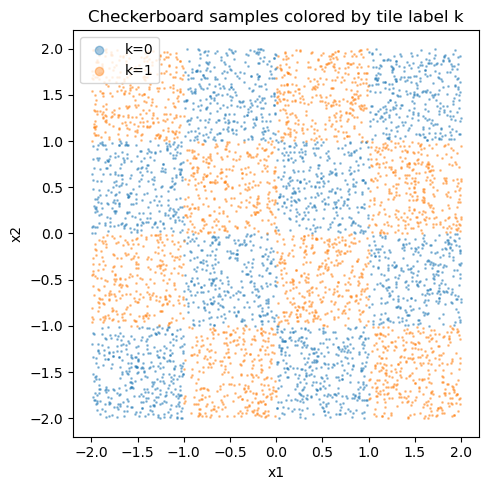

In [5]:
# Visualize samples from the checkerboard dataset
x_vis, k_vis = inf_train_gen(5000, device='cpu')

fig, ax = plt.subplots(figsize=(5, 5))
for k in range(n_classes):
    mask = k_vis == k
    ax.scatter(x_vis[mask, 0], x_vis[mask, 1], s=1, alpha=0.4, label=f'k={k}')

ax.set_aspect('equal')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(markerscale=6)
ax.set_title('Checkerboard samples colored by tile label k')
plt.tight_layout()
plt.show()

In [6]:
class Swish(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        return torch.sigmoid(x) * x


class MLP(nn.Module):
    """
    Velocity field model for joint continuous-discrete data.
    Input:  x = [x_cont (2D), x_disc_onehot (2D)] concatenated = 4D, plus time t
    Output: [vel_cont (2D), logits_disc (2D)]
      - vel_cont  trained with MSE against dx_t (Algorithm 3)
      - logits_disc trained with CrossEntropy against true class (Eq. 19)
    """
    def __init__(self, input_dim: int, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        self.input_dim = input_dim
        self.time_dim  = time_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim), Swish(),
            nn.Linear(hidden_dim, hidden_dim),            Swish(),
            nn.Linear(hidden_dim, hidden_dim),            Swish(),
            nn.Linear(hidden_dim, hidden_dim),            Swish(),
            nn.Linear(hidden_dim, hidden_dim),            Swish(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x  = x.reshape(-1, self.input_dim)
        t  = t.reshape(-1, 1).float().expand(x.shape[0], 1)
        h  = torch.cat([x, t], dim=1)
        return self.main(h).reshape(*sz)

In [7]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [8]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        out         = self.model(x, t)
        vel_cont    = out[:, :n_continuous_features]
        logits_disc = out[:, n_continuous_features:]

        x_disc_t    = x[:, n_continuous_features:]
        probs_disc  = torch.softmax(logits_disc, dim=-1)
        t_col       = t.view(-1, 1).clamp(max=1 - 1e-3)
        vel_disc    = (probs_disc - x_disc_t) / (1.0 - t_col)

        return torch.cat([vel_cont, vel_disc], dim=-1)

In [9]:
lr          = 0.001
batch_size  = 4096
iterations  = 5000
print_every = 1000
hidden_dim  = 512

# Single AffineProbPath over the full joint space R^{D_c} x Delta^{K-1}
path = AffineProbPath(scheduler=CondOTScheduler())

# MLP: input_dim = n_continuous_features + n_discrete_values = 4
vf    = MLP(input_dim=(n_continuous_features + n_discrete_values), hidden_dim=hidden_dim).to(device)
wrapped_vf = WrappedModel(vf)

optim = torch.optim.Adam(vf.parameters(), lr=lr)

start_time = time.time()
for i in tqdm.tqdm(range(iterations)):
    optim.zero_grad()

    # Sample joint data: x_1 = [x_cont, one_hot(k)]  ∈ R^2 x Delta^1
    continuous_samples, discrete_samples = inf_train_gen(batch_size, device)
    one_hot = F.one_hot(discrete_samples, num_classes=n_discrete_values).float()
    x_1 = torch.cat([continuous_samples, one_hot], dim=-1)   # (B, 4)

    # Gaussian source for all dims (both continuous and one-hot)
    x_0 = torch.randn_like(x_1)

    t = torch.rand(batch_size, device=device)

    # Interpolate along joint affine path: x_t = (1-t)*x_0 + t*x_1
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    out          = wrapped_vf(path_sample.x_t, path_sample.t)
    vel_cont     = out[:, :n_continuous_features]
    logits_disc  = out[:, n_continuous_features:]

    # L_cont: MSE on continuous velocity (Algorithm 3)
    cont_loss = torch.pow(vel_cont - path_sample.dx_t[:, :n_continuous_features], 2).mean()

    # L_disc: CrossEntropy on discrete logits (Eq. 19)
    disc_loss = F.cross_entropy(logits_disc, discrete_samples)

    loss = cont_loss + disc_loss
    loss.backward()
    optim.step()

    if (i + 1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:5d} | {:5.2f} ms/step | cont {:6.3f} | disc {:6.3f}'.format(
            i + 1, elapsed * 1000 / print_every, cont_loss.item(), disc_loss.item()))
        start_time = time.time()

 20%|██████████████████▏                                                                       | 1012/5000 [00:08<00:37, 107.37it/s]

| iter  1000 |  8.65 ms/step | cont  1.755 | disc  0.676


 41%|████████████████████████████████████▋                                                     | 2040/5000 [00:16<00:17, 169.46it/s]

| iter  2000 |  7.38 ms/step | cont  1.720 | disc  0.679


 60%|██████████████████████████████████████████████████████▍                                   | 3025/5000 [00:20<00:07, 248.79it/s]

| iter  3000 |  4.68 ms/step | cont  1.682 | disc  0.688


 81%|████████████████████████████████████████████████████████████████████████▌                 | 4028/5000 [00:28<00:04, 212.77it/s]

| iter  4000 |  7.49 ms/step | cont  1.715 | disc  0.681


100%|██████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:33<00:00, 150.55it/s]

| iter  5000 |  5.02 ms/step | cont  1.698 | disc  0.680


In [10]:
step_size      = 0.05
batch_size_inf = 50000
T = torch.linspace(0, 1, 10, device=device)

# Source: 4D Gaussian (2 cont + 2 one-hot dims)
x_init = torch.randn(batch_size_inf, n_continuous_features + n_discrete_values,
                     dtype=torch.float32, device=device)

solver = ODESolver(velocity_model=wrapped_vf)
sol    = solver.sample(time_grid=T, x_init=x_init, method='midpoint',
                       step_size=step_size, return_intermediates=True)
# sol: (10, B, 4)

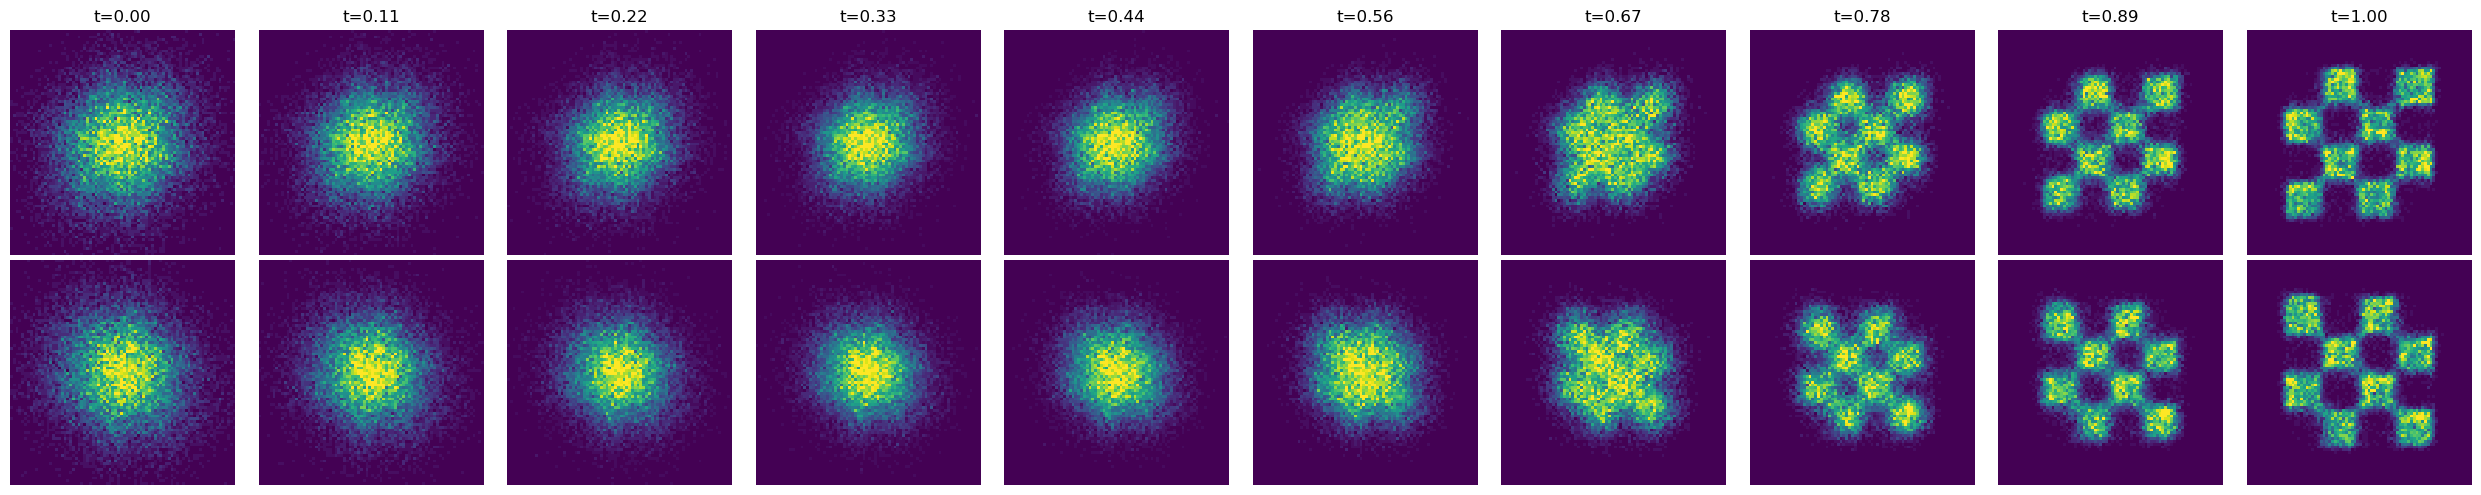

In [ ]:
# Per-class 2D histograms over time.
# At t=1 the discrete dims are soft probabilities; argmax gives the predicted class.
traj_2d      = sol[:, :, :n_continuous_features].detach().cpu().numpy()  # (10, B, 2)
final_labels = sol[-1, :, n_continuous_features:].argmax(dim=-1).cpu().numpy()  # (B,)
T_np         = T.cpu().numpy()

fig, axs = plt.subplots(
    n_classes, len(T_np),
    figsize=(2.5 * len(T_np), 2.5 * n_classes),
    squeeze=False,
)

for k in range(n_classes):
    class_mask = final_labels == k
    for i, t_i in enumerate(T_np):
        pts = traj_2d[i, class_mask]
        H   = axs[k, i].hist2d(pts[:, 0], pts[:, 1], bins=80, range=((-3, 3), (-3, 3)))
        cmax = np.quantile(H[0], 0.99) + 1e-6
        norm = cm.colors.Normalize(vmax=cmax, vmin=0)
        axs[k, i].cla()
        axs[k, i].hist2d(pts[:, 0], pts[:, 1], bins=80, range=((-3, 3), (-3, 3)), norm=norm)
        axs[k, i].set_aspect('equal')
        axs[k, i].axis('off')
        if k == 0:
            axs[k, i].set_title(f't={t_i:.2f}')
        if i == 0:
            axs[k, i].set_ylabel(f'k={k}')

plt.tight_layout()
plt.show()

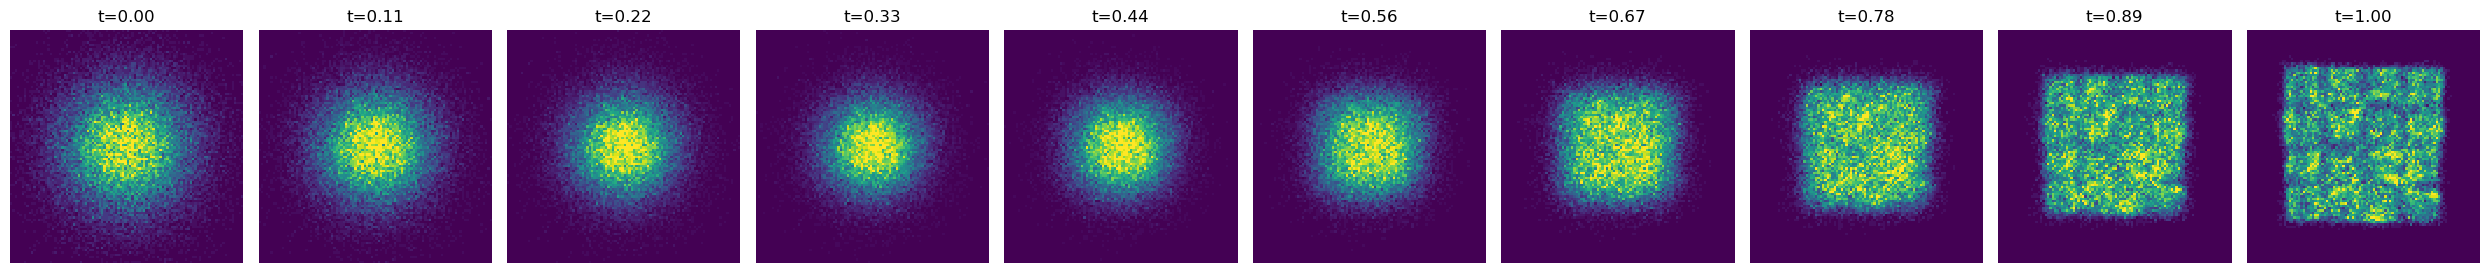

In [12]:
# Combined 2D histogram over time (all classes together).
traj_2d = sol[:, :, :n_continuous_features].detach().cpu().numpy()
T_np    = T.cpu().numpy()

fig, axs = plt.subplots(1, len(T_np), figsize=(2.5 * len(T_np), 2.8), squeeze=False)
axs = axs[0]

for i, t_i in enumerate(T_np):
    pts  = traj_2d[i]
    H    = axs[i].hist2d(pts[:, 0], pts[:, 1], bins=100, range=((-3, 3), (-3, 3)))
    cmax = np.quantile(H[0], 0.99) + 1e-6
    norm = cm.colors.Normalize(vmax=cmax, vmin=0)
    axs[i].cla()
    axs[i].hist2d(pts[:, 0], pts[:, 1], bins=100, range=((-3, 3), (-3, 3)), norm=norm)
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title(f't={t_i:.2f}')

plt.tight_layout()
plt.show()

## Compute and Visualize Model Log-likelihood

For each class k, we fix the one-hot dims to `[k=0]` or `[k=1]` and sweep a 2D grid over the continuous dims. This gives the joint log-likelihood `log p(x_continuous, class=k)` for each class.

/home/aimura/.conda/envs/flow_matching/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


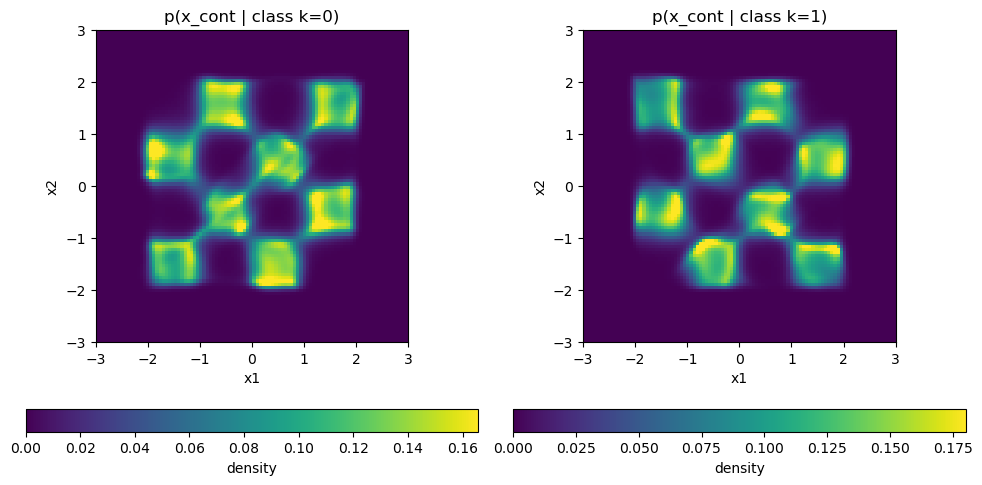

In [13]:
from torch.distributions import Independent, Normal

# Compute p(x_cont | class=k) by fixing the one-hot dims to class k
# and running ODESolver backward over the 2D continuous space only.

class ConditionalVelocityWrapper(ModelWrapper):
    """Exposes only the continuous velocity head, with one-hot fixed to class k."""
    def __init__(self, vf, k: int, device):
        super().__init__(vf)
        self.k   = k
        self.dev = device

    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        B       = x.shape[0]
        one_hot = torch.zeros(B, n_discrete_values, device=self.dev)
        one_hot[:, self.k] = 1.0
        x_full  = torch.cat([x, one_hot], dim=-1)
        out     = self.model(x_full, t)
        return out[:, :n_continuous_features]   # continuous velocity only

# 2D Gaussian source (continuous dims only)
gaussian_log_density = Independent(
    Normal(torch.zeros(n_continuous_features, device=device),
           torch.ones(n_continuous_features, device=device)), 1
).log_prob

grid_size = 100
x_grid    = torch.linspace(-3, 3, grid_size, device=device)
x1g, x2g  = torch.meshgrid(x_grid, x_grid, indexing='ij')
x_cont_grid = torch.stack([x1g.flatten(), x2g.flatten()], dim=1)  # (grid^2, 2)

fig, axs = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5))

for k in range(n_classes):
    cond_solver = ODESolver(velocity_model=ConditionalVelocityWrapper(vf, k=k, device=device))

    _, log_p = cond_solver.compute_likelihood(
        x_1=x_cont_grid,
        method='midpoint',
        step_size=step_size,
        exact_divergence=True,
        log_p0=gaussian_log_density,
    )

    likelihood = torch.exp(log_p).cpu().reshape(grid_size, grid_size).detach().numpy()
    cmax = np.quantile(likelihood, 0.99) + 1e-8
    norm = cm.colors.Normalize(vmax=cmax, vmin=0)

    axs[k].imshow(likelihood.T, extent=(-3, 3, -3, 3), origin='lower', cmap='viridis', norm=norm)
    axs[k].set_title(f'p(x_cont | class k={k})')
    axs[k].set_xlabel('x1')
    axs[k].set_ylabel('x2')
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axs[k],
                 orientation='horizontal', label='density')

plt.tight_layout()
plt.show()